# Relaxation Times, Dynamical Critical Exponent and Other Stuff ...

These notes follow `\notes\diffusion.tex`, here we recap these notes. Note that the master equation can be written in the form of the imaginary time dependent Schrodinger Equation: 

$$\frac{d}{dt} \ket{P(t)} = -H \,\ket{P(t)} $$

The solutions are given by the different eigenvectors of the system written as $\ket{\phi_n} = \sum_{\eta}\, a_n(\eta\,) \ket{\eta}$ in the notes where $\eta$ are configurations of the chain such as $\eta = (0, 1, 1, 2, 1, \cdots)$. We also assume that the elements of $\ket{P(0)}$ sum to $1$:

$$\ket{P(t)} = e^{-H t} \ket{P(0)} = \sum_{n} c_n \,e^{-E_n t} \ket{\phi_n} = \sum_{n} c_n\, \ket{\phi_n}\, e^{-E_n t} = c_0 ,\ket{\phi_0} \, e^{-E_0 t} + c_1 ,\ket{\phi_1} \, e^{-E_1 t} + \cdots $$

We know that there will always be a stationary distribution, which is a distribution across the system's states that remains constant over time, because the master equation $d/dt \,\ket{P(t)}=-H\ket{P(t)}$ describes probability conserving dynamics. Essentially, the total probability must remain equal to one for all time. A stationary distribution is a probability vector $\ket{P_{ss}}$ whose time derivative is zero, so it satisfies $d/dt \,\ket{P_{ss}}=0$. 

Substituting this into the master equation gives $H\ket{P_{ss}}=0$. Thus the stationary state is the eigenvector of $H$ with eigenvalue $E_0=0$. Its important to realize that the stationary state does not mean that the microscopic system stops evolving particles will continue hopping or exchanging forever. It means that the probability distribution over configurations no longer changes with time.

Now each eigenvector $\ket{\phi_n}$ has its own relaxation time which is defined as the time a system needs to return to its an equilibrium state after being disturbed. Now since these are stocastic systems there is no percise "moment a system has reached its equilibrium state", so we have to define our own metrics for what we call the relaxation time. Since each eigenmode decays exponentially, the full probability state approaches stationarity as a sum of exponentially decaying modes. Therefore we can sort of piggy off of something called the [characteristic time of an exponential decay](https://www.reddit.com/r/explainlikeimfive/comments/rywq9g/eli5_what_is_characteristic_time/) which is the time it takes for a quantity to decrease to $1/e$ of its initial value. This is because for an exponential decay of the form $e^{-Et}$,

$$\frac{1}{e} = e^{-E \tau} \Rightarrow \tau = \frac{1}{E}$$

We will use this metric to asses the relaxation time since we expect the probability distribution $\ket{P(t)}$ to decay exponentially to $\ket{P_{ss}}$ which is the stationary state distribution (the probability ditribution in the long run). Now realize that from $\ket{P(t)}$ the relaxation time towards equilibrium $\tau$ is dominated by the nonzero eigenvalue with the smallest real part (which we will call $E_1$ since $E_0=0$), this is because at long times, all the faster decaying modes become negligible, and the slowest remaining mode dominates the approach to equilibrium. This is the important consept that will be demonstrated below. This is why we can say: 

$$\ket{P(t)} - \ket{P_{ss}} \sim c_1 e^{-E_1 t}\ket{\phi_1}, \quad \tau \sim \frac{1}{Re(E_1)}$$

Say we want to look at a master equation with matrix dimension $N=10$, think about what this means. For the 1D chain the dimension of the Markov Generator / Hamiltonian is equal to the number of configurations. Lets say there are $L$ total sites on the chain and there are $d$ species and $l_i$ number of the $i$th species where $i = 0, \cdots, d-1$ so $l_0 + \cdots + l_{d-1} = L$, then we know from combinatorics that the number of configurations is given as the [multinomial coefficient](https://en.wikipedia.org/wiki/Multinomial_theorem), given as:

$$ N = \frac{L!}{l_0! \cdots l_{d-1}!} $$

So for a chain of length $L=5$ with just two species ($d=2$), three of one species and two of the other ($l_0=2$ and $l_1=3$), gives a dimension $10$ Hamiltonian, this faster than exponential scaling with complexity is the reason why we are resorting to simulating the relaxation time instead of solving for it.

We define the sparse matrix below which will represent this Markov Generator/Hamiltonian, where recall that we define the Hamiltonian of the system as simply the negitive of the matrix $M$. 

In [4]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [5]:
N = 10
M = np.zeros((N, N))

for i in range(N):
    if i > 0:
        M[i - 1, i] = 1.0
    if i < N - 1:
        M[i + 1, i] = 1.0

for j in range(N):
    M[j, j] = -np.sum(M[:, j])

H = -M

In [6]:
print(H)

[[ 1. -1. -0. -0. -0. -0. -0. -0. -0. -0.]
 [-1.  2. -1. -0. -0. -0. -0. -0. -0. -0.]
 [-0. -1.  2. -1. -0. -0. -0. -0. -0. -0.]
 [-0. -0. -1.  2. -1. -0. -0. -0. -0. -0.]
 [-0. -0. -0. -1.  2. -1. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -1.  2. -1. -0. -0. -0.]
 [-0. -0. -0. -0. -0. -1.  2. -1. -0. -0.]
 [-0. -0. -0. -0. -0. -0. -1.  2. -1. -0.]
 [-0. -0. -0. -0. -0. -0. -0. -1.  2. -1.]
 [-0. -0. -0. -0. -0. -0. -0. -0. -1.  1.]]


Since this Hamiltonian is small we can exactally solve for the eigenvalues and eigenvectors of the equation. Below `E` represents the eigenvalues (energy levels of the Hamiltonian) and `V` represents the eigenvectors.

In [8]:
E, V = np.linalg.eig(H)

idx = np.argsort(np.real(E))
E = np.real(E[idx])
V = np.real(V[:, idx])

The eigenvalues and their eigenvectors are printed below, recall from above that the eigenvalue that is zero corresponds to the eigenvector that (when normalized) that represents the stationary distribution meaning that the system will tend to this position in the long time, we will show this in the first graph below.

In [10]:
print(f"Eigenvalues of H: {np.round(E, 3)}")

Eigenvalues of H: [0.    0.098 0.382 0.824 1.382 2.    2.618 3.176 3.618 3.902]


In [11]:
for eigenvalue, eigenvector in zip(E, V):
    print(f"For energy {np.round(eigenvalue, 3)} the eigenvector is: {np.round(eigenvector, 3)}")

For energy 0.0 the eigenvector is: [ 0.316  0.442  0.425  0.398  0.362 -0.316  0.263 -0.203 -0.138 -0.07 ]
For energy 0.098 the eigenvector is: [ 0.316  0.398  0.263  0.07  -0.138  0.316 -0.425  0.442  0.362  0.203]
For energy 0.382 the eigenvector is: [ 0.316  0.316 -0.    -0.316 -0.447  0.316  0.    -0.316 -0.447 -0.316]
For energy 0.824 the eigenvector is: [ 0.316  0.203 -0.263 -0.442 -0.138 -0.316  0.425 -0.07   0.362  0.398]
For energy 1.382 the eigenvector is: [ 0.316  0.07  -0.425 -0.203  0.362 -0.316 -0.263  0.398 -0.138 -0.442]
For energy 2.0 the eigenvector is: [ 0.316 -0.07  -0.425  0.203  0.362  0.316 -0.263 -0.398 -0.138  0.442]
For energy 2.618 the eigenvector is: [ 0.316 -0.203 -0.263  0.442 -0.138  0.316  0.425  0.07   0.362 -0.398]
For energy 3.176 the eigenvector is: [ 0.316 -0.316 -0.     0.316 -0.447 -0.316  0.     0.316 -0.447  0.316]
For energy 3.618 the eigenvector is: [ 0.316 -0.398  0.263 -0.07  -0.138 -0.316 -0.425 -0.442  0.362 -0.203]
For energy 3.902 the ei

The printed value below represents the stationary state probabiliy vector meaning in the long run what the probability the system will be in each configuration, we will show that the system tends to this in the first figure below. Note that `P_t` is $\ket{P(t)}$ over the range of times in `times`.

In [13]:
P_stationary_state = np.real(V[:, 0])
P_stationary_state = P_stationary_state / np.sum(P_stationary_state)

print(f"The stationary state is given as {P_stationary_state}")

The stationary state is given as [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


In [14]:
P0 = np.zeros(N)
P0[0] = 1.0

times = np.linspace(0, 80, 800)
P_t = np.array([sp.linalg.expm(-H * t) @ P0 for t in times])

Recall that it is the distance from stationary state that exibits the exponential relaxation behavior that we want to characterize. Plotted below are the time varying probabilities of the $10$ components of the configuration space,

$$\ket{P(t)} = e^{-H t} \, \ket{P(0)}, \quad \begin{pmatrix} P_0(t) \\ P_1(t) \\ \vdots \\ P_{9}(t) \end{pmatrix} = e^{-H t} \, \begin{pmatrix} P_0(0) \\ P_1(0) \\ \vdots \\ P_{9}(0) \end{pmatrix} $$

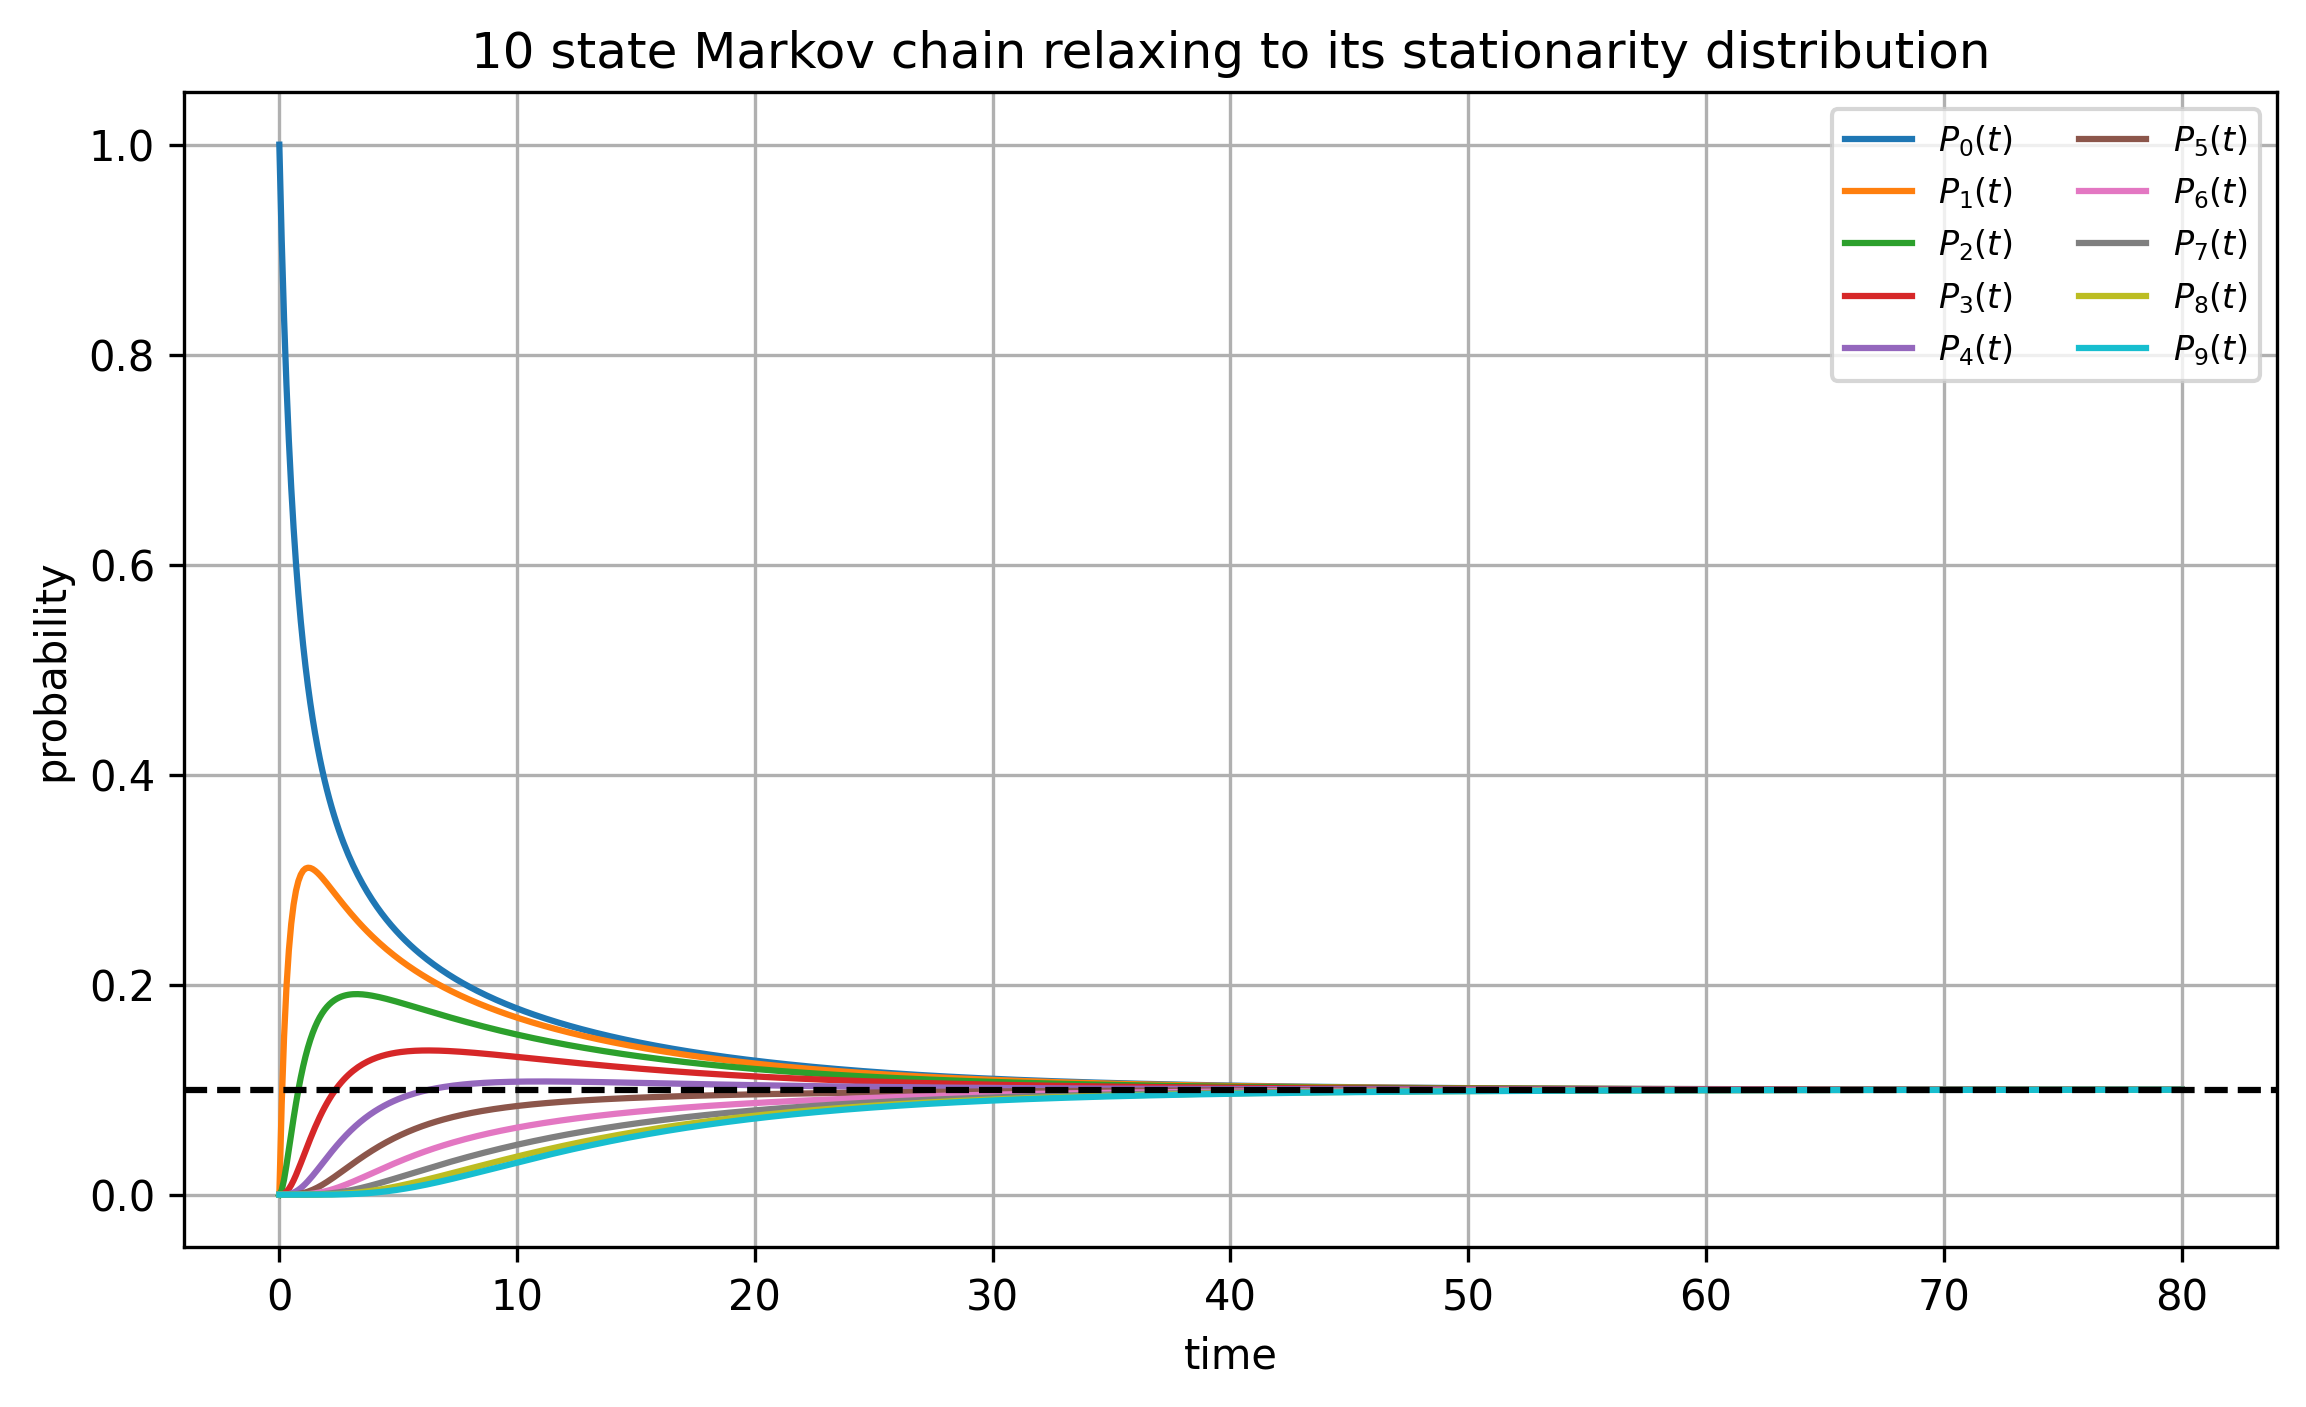

In [16]:
dist = np.linalg.norm(P_t - P_stationary_state, axis=1)

plt.figure(figsize=(9, 5), dpi=300)

for i in range(N):
    plt.plot(times, P_t[:, i], label=fr"$P_{i}(t)$")

plt.axhline(0.1, linestyle="--", color="black")

plt.xlabel("time")
plt.ylabel("probability")
plt.title("10 state Markov chain relaxing to its stationarity distribution")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)

plt.show()

To show the idea that the the relaxation time towards equilibrium $\tau$ is dominated by the nonzero eigenvalue (called $E_1$) with the smallest real part, we plot the $\log$ of `dist`$\,= \ket{P(t)} - \ket{P_{ss}}$. This is since we say that,

$$\|\ket{P(t)} - \ket{P_{ss}}\| \sim c_1 e^{-E_1 t}, \quad \tau \sim \frac{1}{Re(E_1)} \Rightarrow \ln \|\ket{P(t)} - \ket{P_{ss}}\| \sim \ln|c_1| -\frac{t}{\tau}$$

Below we have also plotted all of the eigenvalues as exponentials, the goal is to demonstrate the consept that in long time the relaxation is controlled by the smallest nonzero eigenvalue. This is shown by the fact that `dist` or $\|\ket{P(t)} - \ket{P_{ss}}\|$ denoted in black below aligns with the smallest eigenvalue $E_1$ as a exponential.

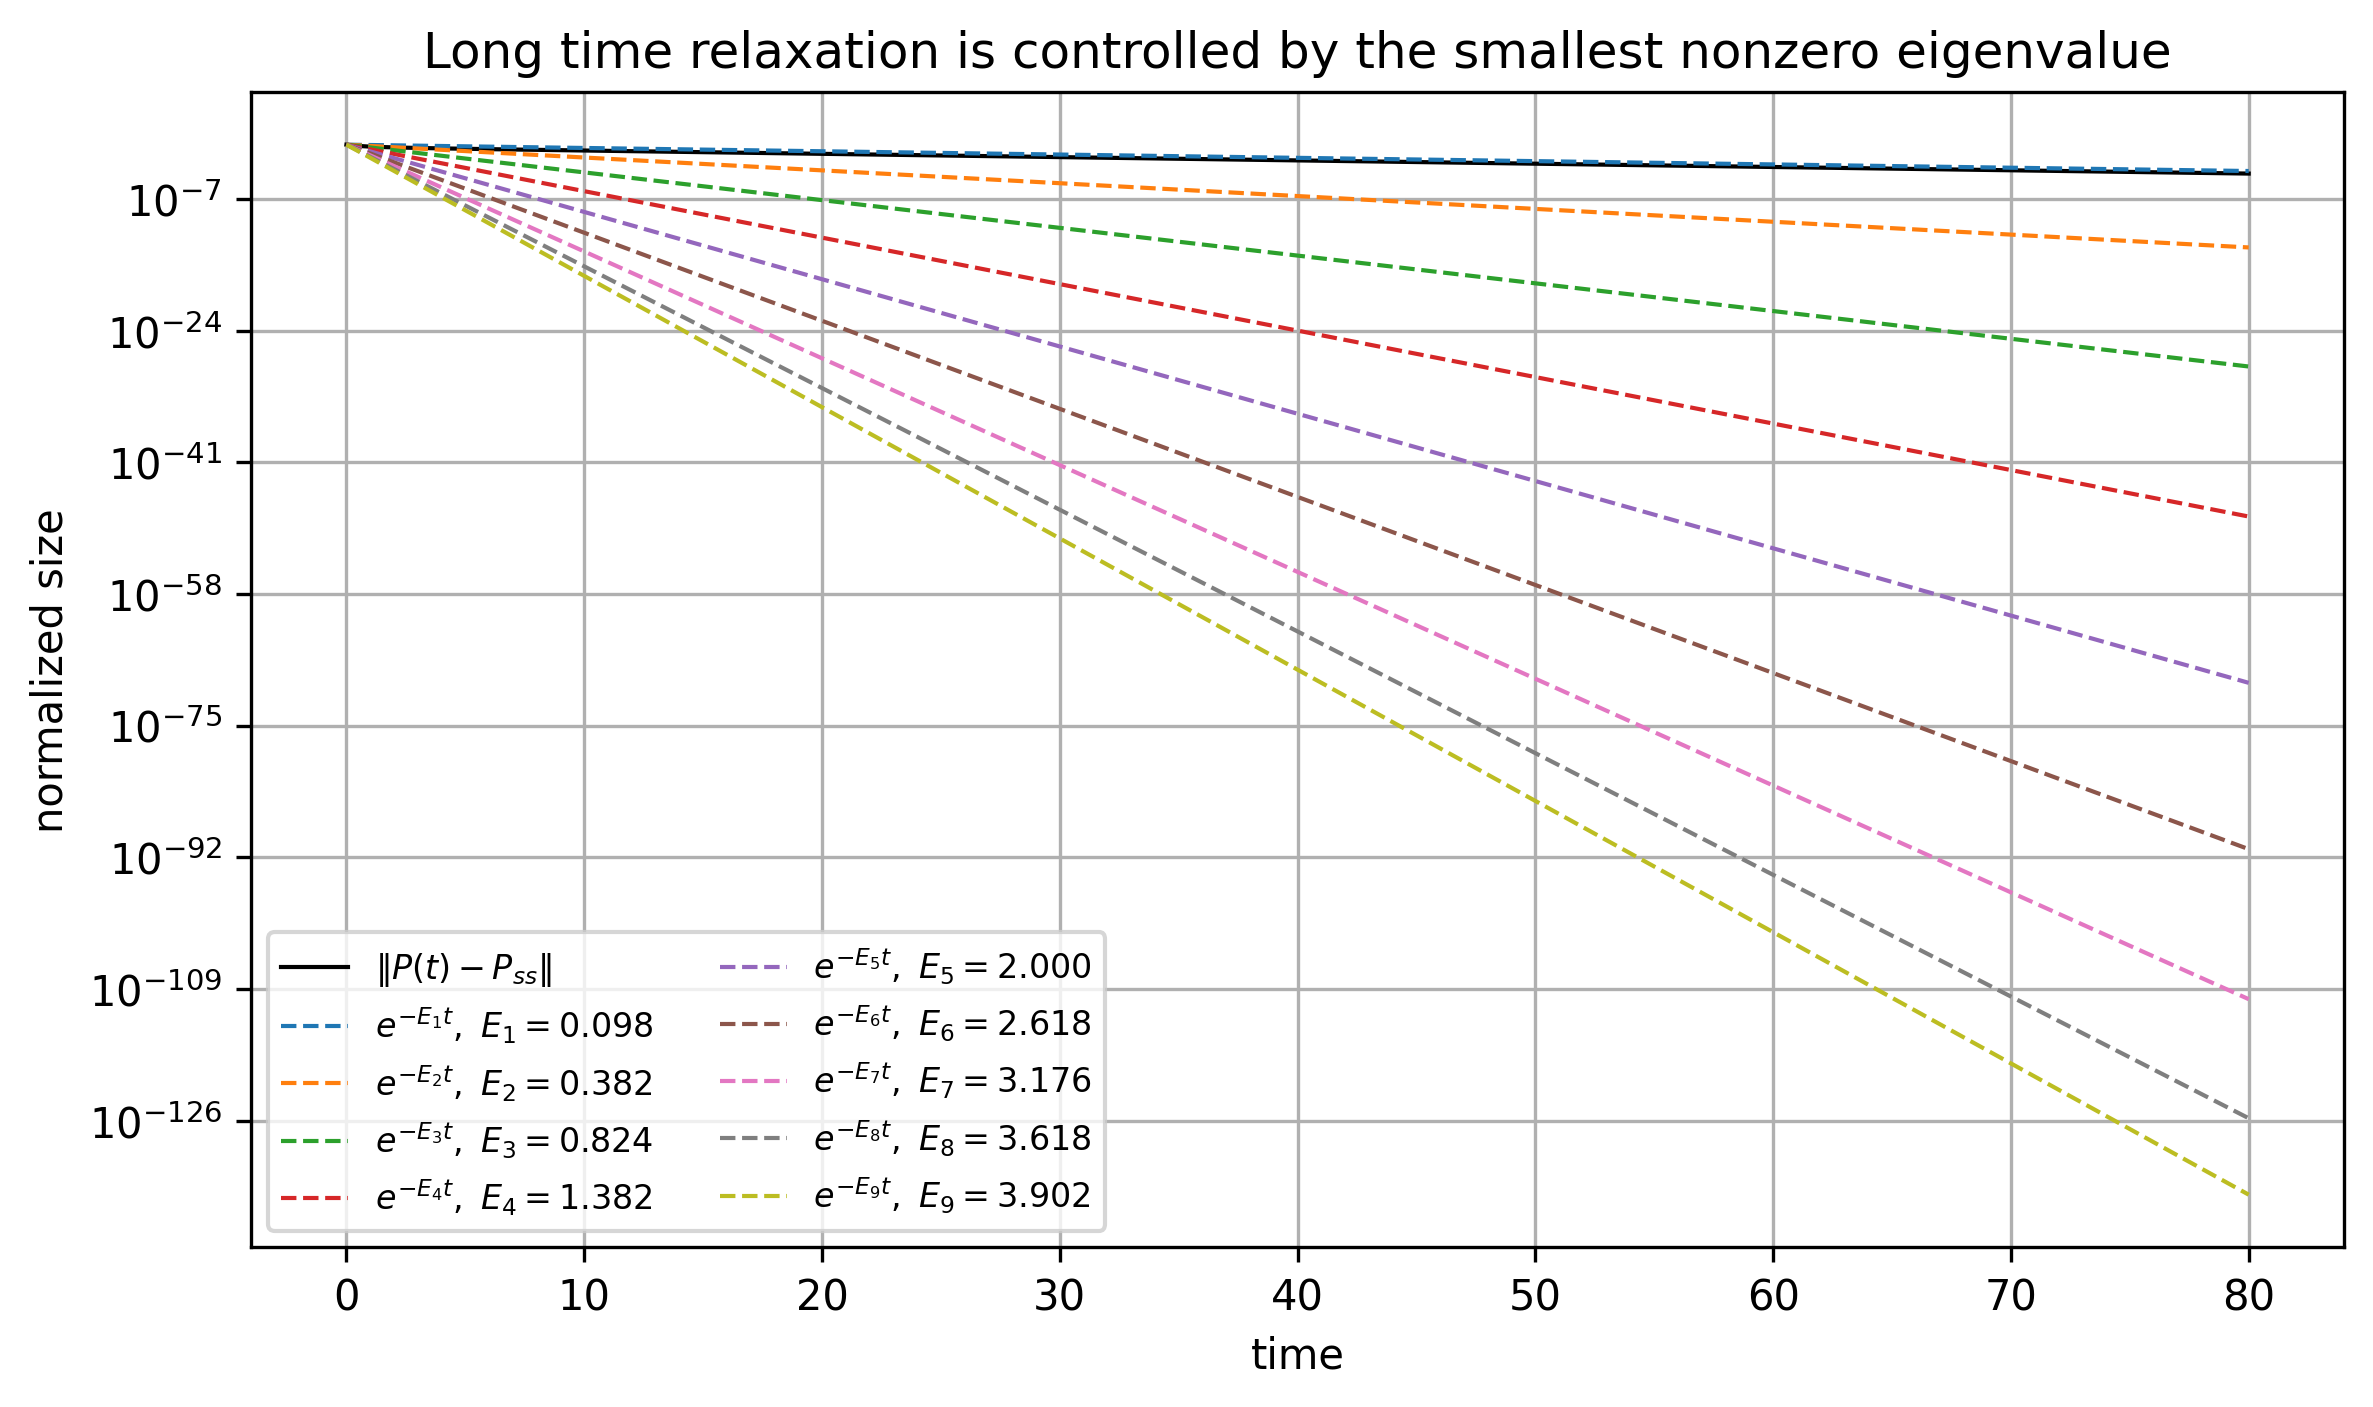

In [18]:
# Plot all exponential eigenmode decays
plt.figure(figsize=(9, 5), dpi=300)

plt.semilogy(times, dist / dist[0], color="k", linewidth=1, label=r"$\|P(t)-P_{ss}\|$")

for n in range(1, N):
    plt.semilogy(times, np.exp(-E[n] * times), "--", label=fr"$e^{{-E_{n}t}},\ E_{n}={E[n]:.3f}$", linewidth=1)

plt.xlabel("time")
plt.ylabel("normalized size")
plt.title("Long time relaxation is controlled by the smallest nonzero eigenvalue")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)

plt.show()

# Computational Determination of Relaxation Time

It follows to now to show how the relaxation time is measured for a simulated diffusion system. Note that we were able to do the simulation above since we could exactally solve for the Hamiltonian's eignevalues. However the dimension of the matrix was only $10$ which corresponded to a chain of length $5$, if we want to simulate a typical chain of say $300$, of three equally distributed species then the dimension of the matrix which is so large when I try to just compute the dimension itself it is undefined!

$$N = \frac{300!}{100!\,100!\,100!} \sim \text{undef}$$

We can not solve for the relaxation time like we did above. However since the chain is periodic it allows us to exploit a certain symmetry within the system. In particular the first Fourier mode of the density function represents the longest wavelength nonconstant fluctuation in the system, and it would be the slowest mode to relax. Shorter wavelength fluctuations decay quickly because they only require local  rearrangements while the first Fourier mode corresponds to a system size density variation.

The $k$th Fourier mode of the species $\alpha$ is given below where $n_\alpha$ is the density of the species and is defined as $n_\alpha(j)$ which is $1$ if $\alpha$ equals the species at site $j$ of chain, else $0$.

$$X_{k, \alpha}(t) = \sum_{j=0}^{L-1} n_{\alpha} e^{2\pi ikj/L}$$

After we define an instance of `MultiSpeciesExclusionProcess`, say its called `process` which is shuffled to start then we call the function `fourier_time_series` of `process` which takes in the mode we want to sample (so one in our case), the species we are intrested in and the number of samples we should take (note that each sample runs the nearest neighbor swap `L` times inside the C++ code). The plots below will show the real, imaginary and the magnitude of the fourier times series. 

In [20]:
import sys
sys.path.append("..")

from src.utils.autocorrelation import autocorrelation
from src.utils.msep import MultiSpeciesExclusionProcess
from src.utils.relaxation_time import relaxation_time

In [21]:
rates_matrix = np.triu(np.ones((3, 3), dtype=np.float64), k=1)

process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=102, shuffle=True)
X = process.fourier_time_series(n_samples=10000, mode=1, species=0)

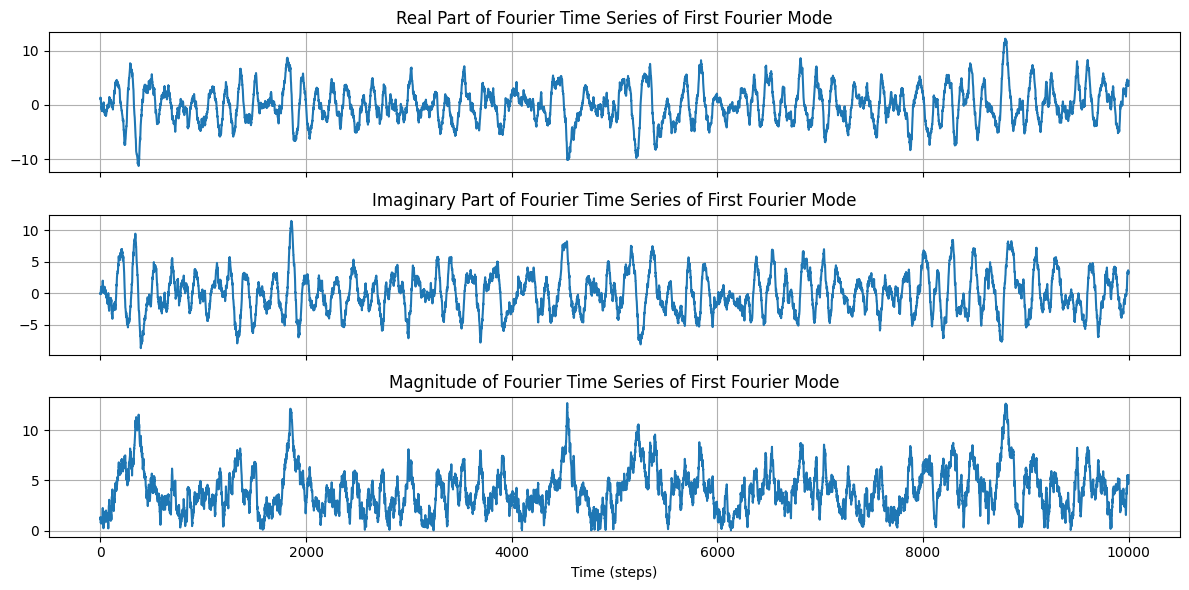

In [22]:
fig, ax = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

ax[0].plot(np.real(X))
ax[0].set_title("Real Part of Fourier Time Series of First Fourier Mode")
ax[0].grid(True)

ax[1].plot(np.imag(X))
ax[1].set_title("Imaginary Part of Fourier Time Series of First Fourier Mode")
ax[1].grid(True)

ax[2].plot(np.abs(X))
ax[2].set_title("Magnitude of Fourier Time Series of First Fourier Mode")
ax[2].grid(True)
ax[2].set_xlabel("Time (steps)")

plt.tight_layout()
plt.show()

As shown above we can clearly see that the Fourier mode itself does not visibly decay it keeps fluctuating because the system continues hopping and exchanging continuously. Note though that relaxation does not mean we expect $X(t)$ to go to zero, all relaxation means is that $X(t)$ has "forgot" its previous value. How do we mathematically characterize fogetting? We use [autocorrelation](https://en.wikipedia.org/wiki/Autocorrelation).

The formula for autocorrelation is given as,

$$ C(\tau) = \bra{X(t+\tau)}\ket{X(t)}_t$$

For a discrete time signal,

$$ C(\ell) = \frac{1}{N-l} \sum_{t=0}^{N-\ell-1} X_{t+\ell} X^*_{t}$$

Where we also usually normalize it so it is one at point zero, 

$$ \hat{C(\ell)} = \frac{C(\ell)}{C(0)}$$

The reason this extracts useful information from a messy Fourier time series is that the random fluctuations average out. If $X(t + \ell)$ is still related to $X(t)$, then the product

$$X(t + \ell)X(t)^*$$

has a consistent positive contribution when averaged over $t$. But once the system has forgotten its earlier state, $X(t + \ell)$ and $X(t)$ are essentially unrelated, so their products cancel out on average. We apply the imported function `autocorrelation`, which is a function created as a wrapper ontop of a `scipy` function that gets the autocorrelation. 

The magnitude of the autocorrelation is given in the plot below. As shown it exhibits a decay, and from that decay with the other function created `relaxation_time`, the relaxation time (the time in which the decay passes $1/e$) is solved for as shown below with the dashed lines. 

In [24]:
C = autocorrelation(X)
tau = relaxation_time(C)

print(f"Relaxation time: {tau}")

Relaxation time: 100.03883197720285


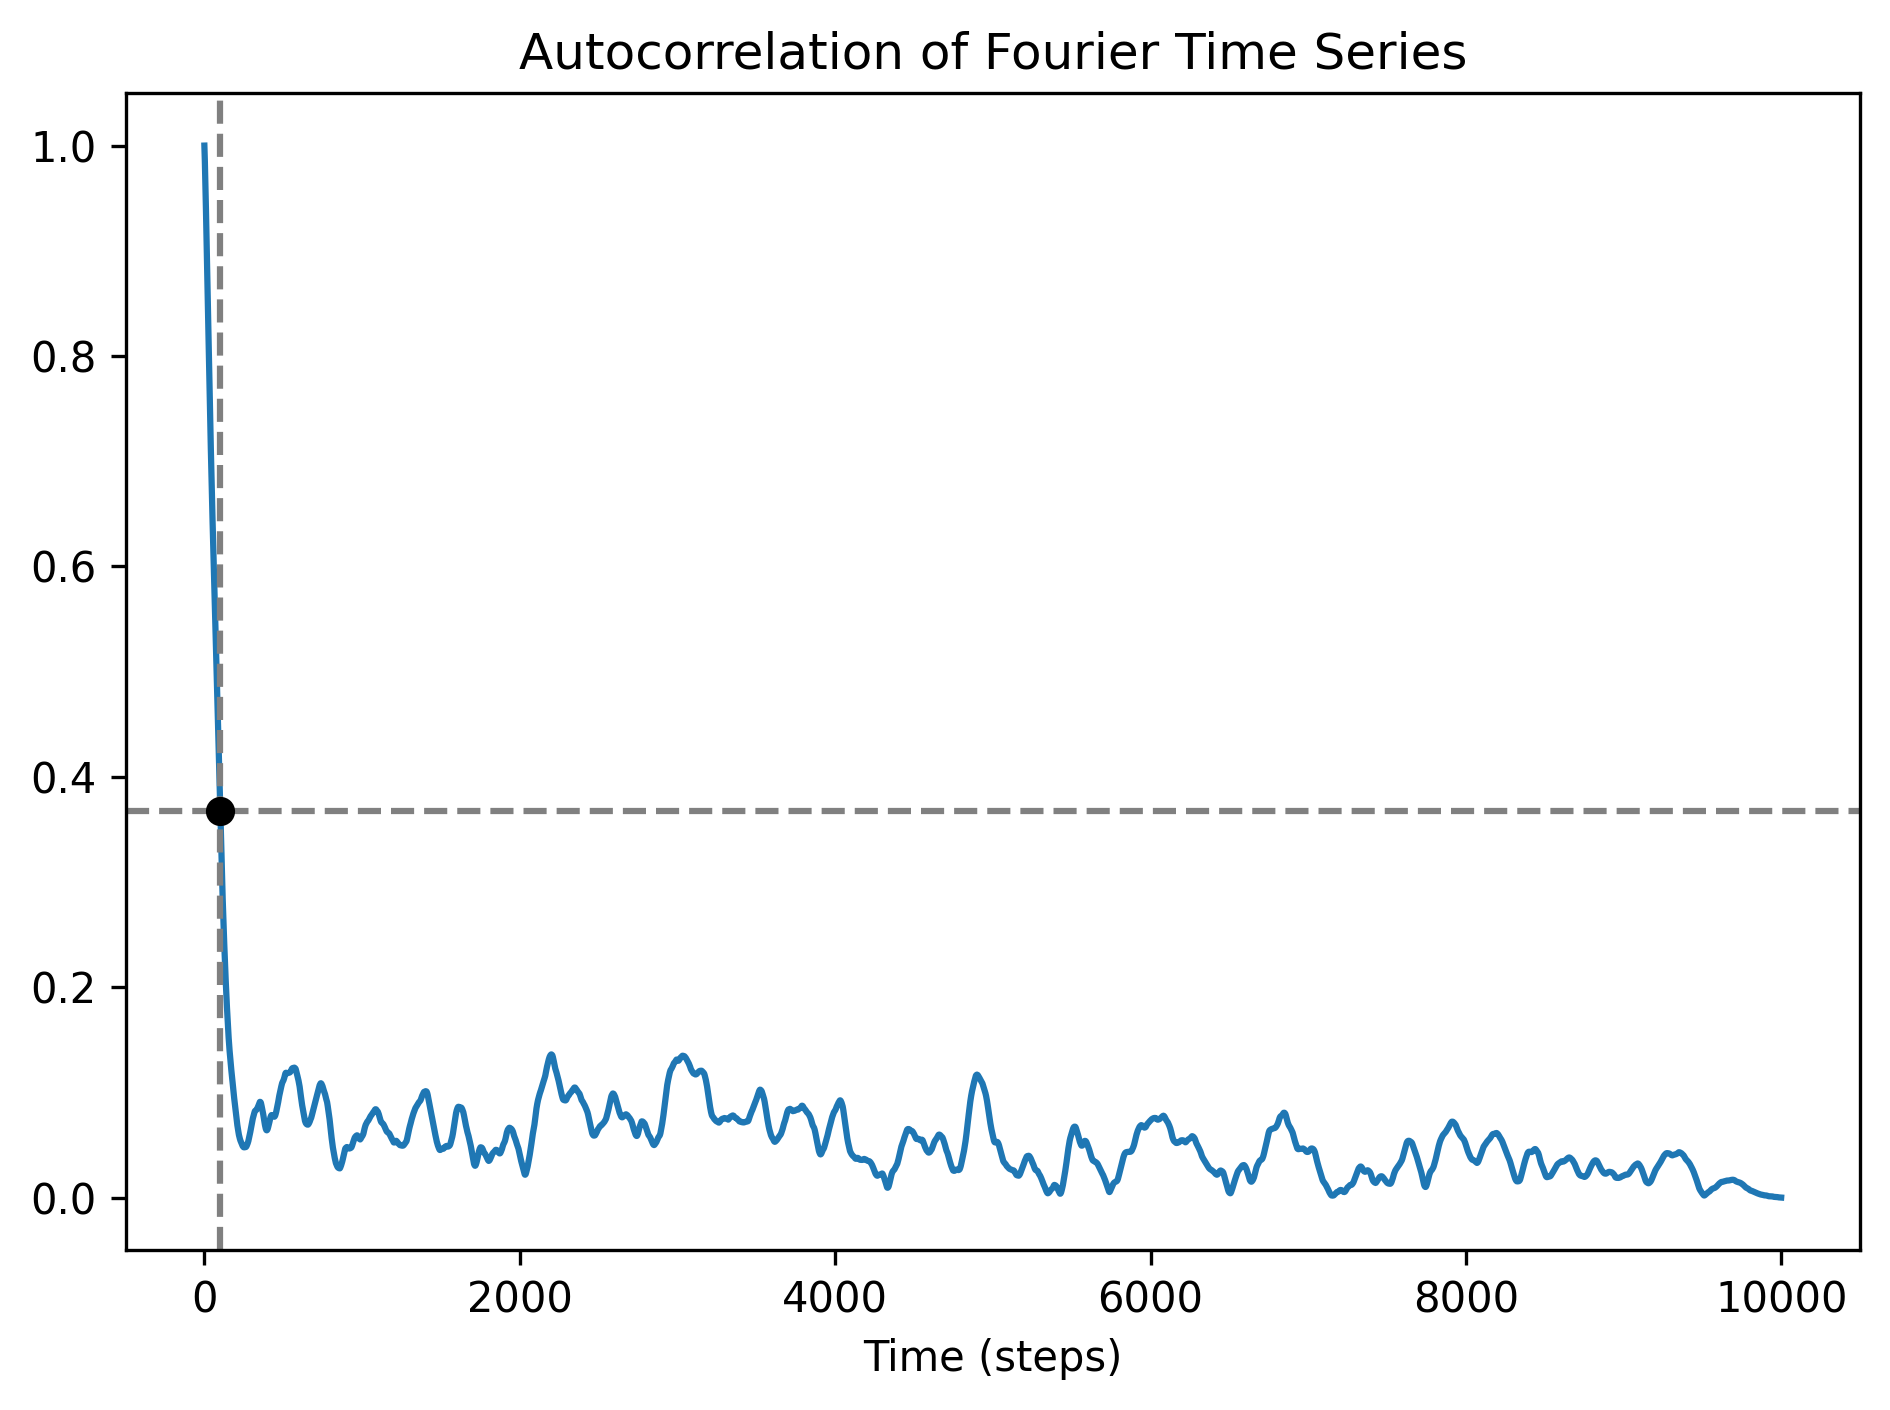

In [25]:
fig, ax = plt.subplots(dpi=300)
ax.plot(np.abs(C))
ax.axvline(tau, linestyle="--", color="gray")
ax.axhline(1/np.e, linestyle="--", color="gray")
ax.plot(tau, 1/np.e, "ko")
ax.set_xlabel("Time (steps)")
ax.set_title("Autocorrelation of Fourier Time Series")

plt.tight_layout()
plt.show()

# Computational Determination of Dynamical Critical Exponent

Using this we can now solve for the dynamical critical exponent, simply all we do is loop through different simulations for different sizes of the chain length. Note that we expect, 

$$\tau \sim L^z \Rightarrow \ln(\tau) \sim z\ln(L) + \text{constants...}$$

Therefore if we plot $\ln(L)$ against $\ln(\tau)$ then the slope should be $z$. 

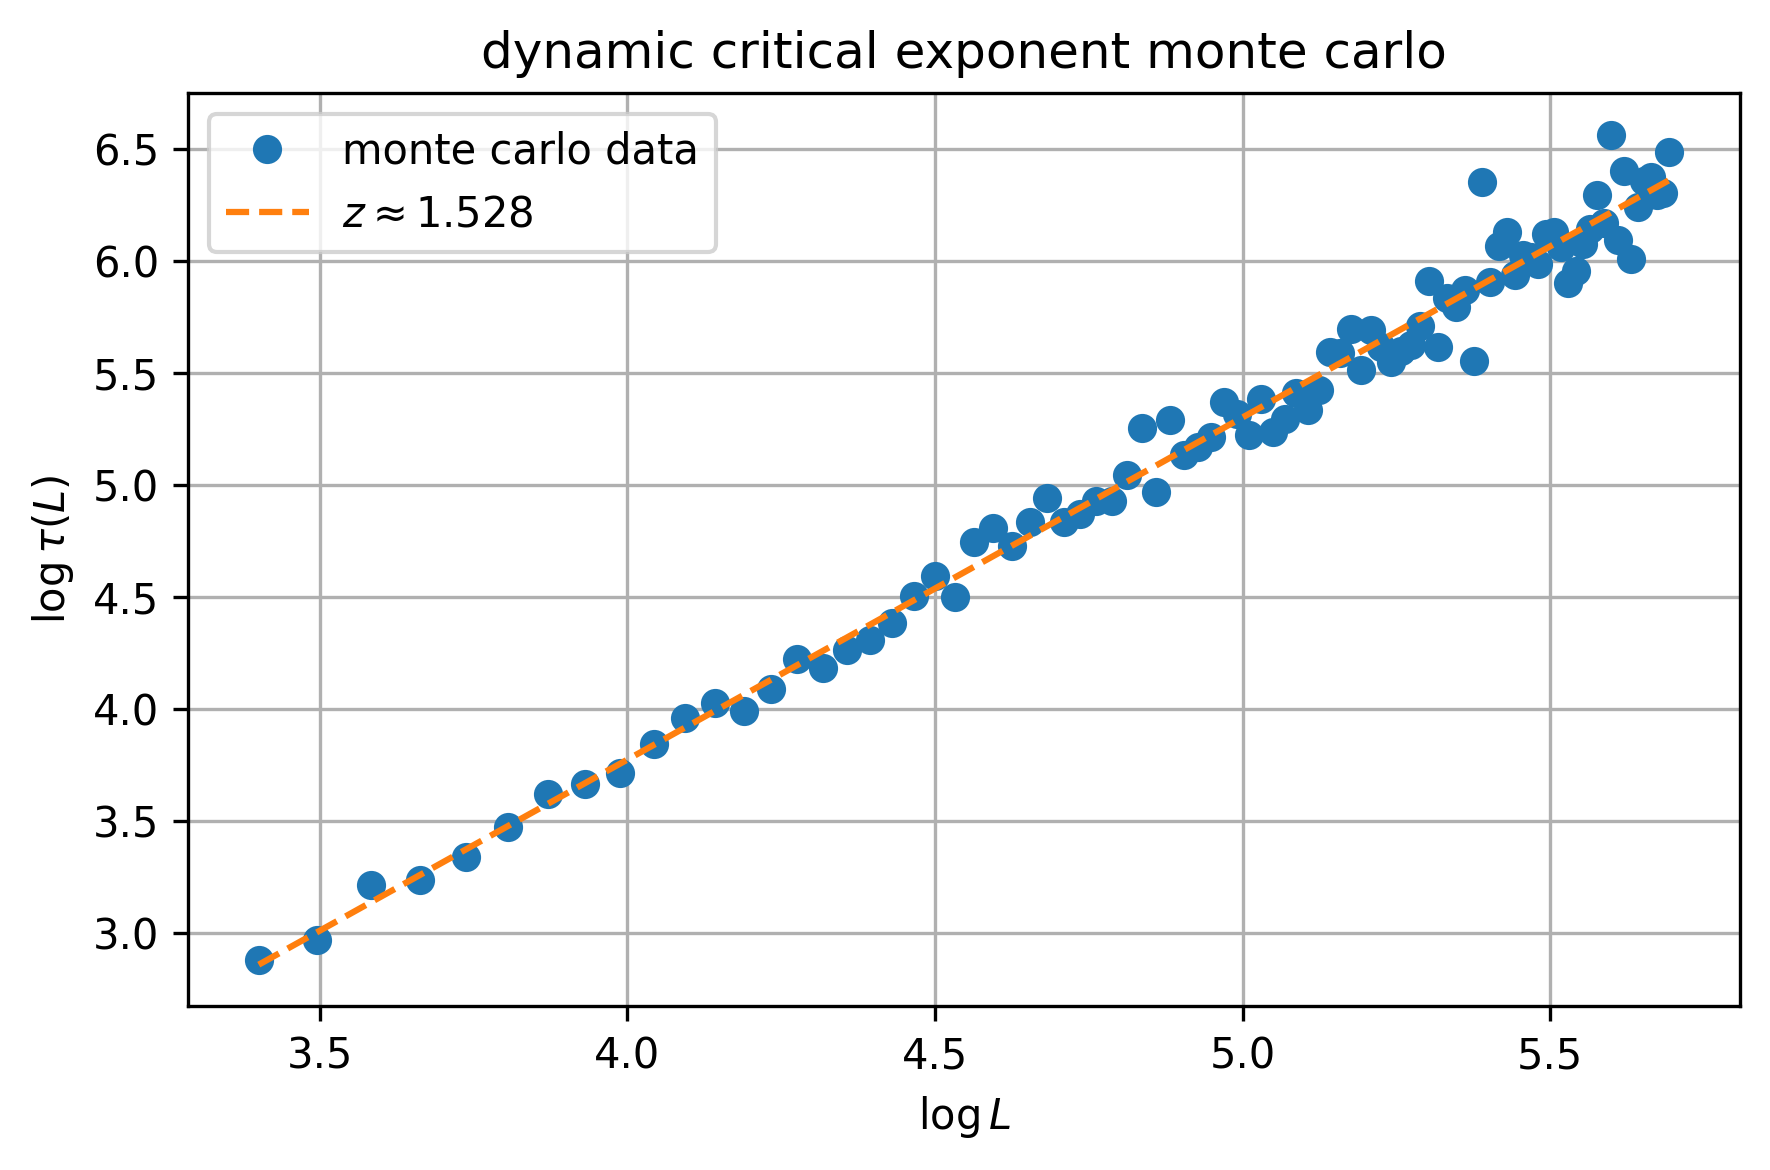

In [27]:
L_values = np.arange(30, 300, 3)
rates_matrix = np.triu(np.ones((3, 3), dtype=np.float64), k=1)

taus = []

for L in L_values:
    
    process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=L)
    
    X = process.fourier_time_series(n_samples=30000, species=0)
    C = autocorrelation(X)
    taus.append(relaxation_time(C))

taus = np.array(taus)
valid = np.isfinite(taus) & (taus > 0)

logL = np.log(L_values[valid])
logtau = np.log(taus[valid])      

z, intercept = np.polyfit(logL, logtau, 1)
fit = intercept + z * logL

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(logL, logtau, "o", label="monte carlo data")
plt.plot(logL, fit, "--", label=fr"$z \approx {z:.3f}$")

plt.xlabel(r"$\log L$")
plt.ylabel(r"$\log \tau(L)$")
plt.title(r"dynamic critical exponent monte carlo")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()